In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = pd.read_csv("sdss.csv")

## With feature 'i'

In [3]:
features = ['u', 'g', 'r', 'i', 'z']
X = data[features]
y = data['class']  

In [4]:
y = y.map({'GALAXY': 0, 'STAR': 1, 'QSO': 2})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) #might need to fiddle with this

In [5]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

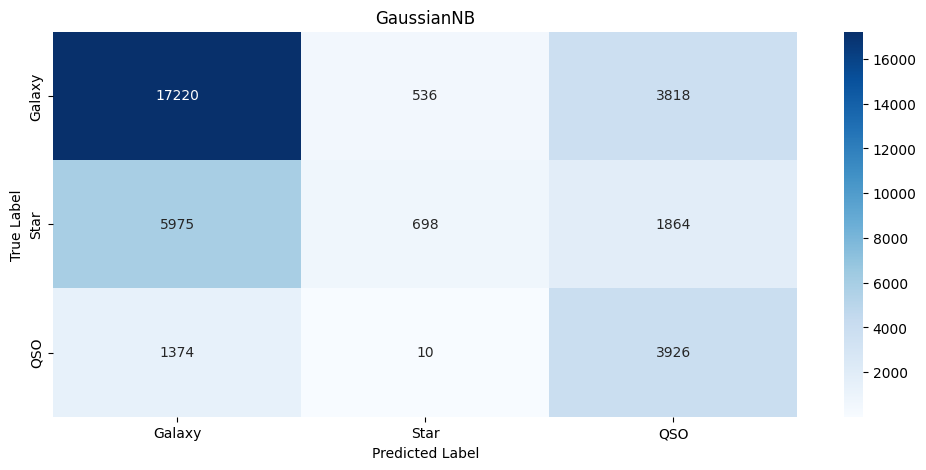

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))  
cm = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Galaxy', 'Star', 'QSO'], yticklabels=['Galaxy', 'Star', 'QSO'], ax=ax)
ax.set_title("GaussianNB")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.show()


## Without feature 'i'

In [7]:
features = ['u', 'g', 'r', 'z']
X = data[features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

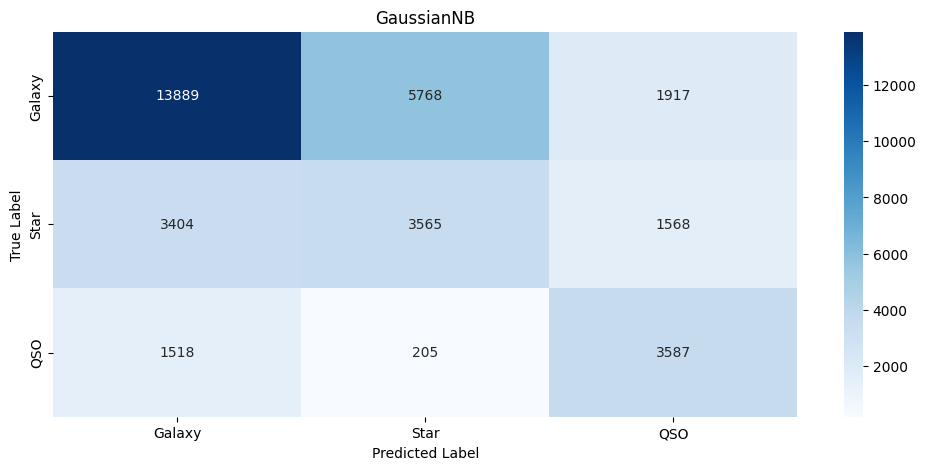

In [9]:
fig2, ax = plt.subplots(1, 1, figsize=(12, 5)) 
cm = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Galaxy', 'Star', 'QSO'], yticklabels=['Galaxy', 'Star', 'QSO'], ax=ax)
ax.set_title("GaussianNB")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.show()


comparing first and second confusion matrix:

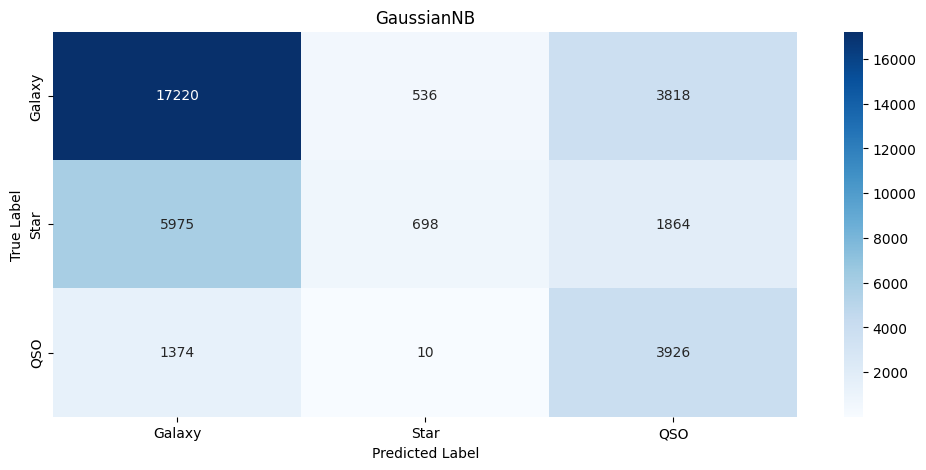

In [10]:
fig


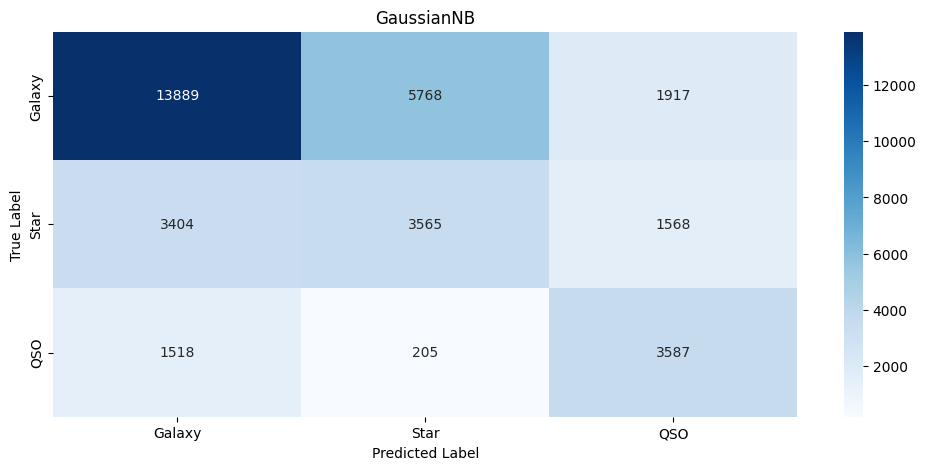

In [11]:
fig2

### Error margin has reduced in some ways and increased in others. Removing feature i is not yielding any good results. Let's try another approach.

## Handling outliers with z score

In [12]:
from scipy import stats



this removes outliers beyond 3 standard deviations

In [13]:
z_scores = np.abs(stats.zscore(X))
X_clean = X[(z_scores < 3).all(axis=1)]
y_clean = y[(z_scores < 3).all(axis=1)]
